In [2]:
import os
import ast
import wfdb
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, f1_score  # ADDED f1_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import warnings
warnings.filterwarnings('ignore')

In [3]:
#  CONFIGURATION
 
class Config:
    # Paths
    DATASET_PATH = Path("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3")
 
    # Training
    BATCH_SIZE          = 32
    EPOCHS              = 100
    LR_MAX              = 1e-3
    LR_MIN              = 1e-6
    WARMUP_EPOCHS       = 5
    WEIGHT_DECAY        = 1e-4
 
    # Model
    CNN_CHANNELS        = [64, 128, 256, 512]
    TRANSFORMER_LAYERS  = 6
    NUM_HEADS           = 8
    DROPOUT             = 0.2
 
    # Augmentation
    USE_MIXUP           = True
    MIXUP_ALPHA         = 0.2
    AUG_PROB            = 0.7
 
    # Advanced
    LABEL_SMOOTHING     = 0.1
    GRADIENT_ACCUM_STEPS = 2
 
 
# Set seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
 
print("HYBRID CNN-TRANSFORMER — ECG CLASSIFICATION")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

HYBRID CNN-TRANSFORMER — ECG CLASSIFICATION
PyTorch : 2.5.1+cu121
CUDA    : True


In [4]:
import wandb

wandb.init(
    project="Hybrid-CNN-Transformer-ECG-notebooks_individual_notebooks",
    name="Hybrid-CNN-Transformer"
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sdhakal13 (sdhakal13-youngstown-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
# DATA LOADING 
df = pd.read_csv(Config.DATASET_PATH / 'ptbxl_database.csv', index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(ast.literal_eval)
 
agg_df = pd.read_csv(Config.DATASET_PATH / 'scp_statements.csv', index_col=0)
 
target_labels = ['NORM', 'AFIB', 'PVC', 'LVH', 'IMI', 'ASMI', 'LAFB', 'IRBBB']
 
def get_labels(scp_codes):
    labels = np.zeros(len(target_labels), dtype=np.float32)
    for code, confidence in scp_codes.items():
        if code in target_labels and confidence >= 50:
            labels[target_labels.index(code)] = 1.0
    return labels
 
df['labels'] = df.scp_codes.apply(get_labels)
df = df[df['labels'].apply(lambda x: x.sum() > 0)].reset_index(drop=True)
 
y_all     = np.stack(df['labels'].values)
X_indices = df.index.values
 
# Train / Val / Test — 70 / 10 / 20
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(msss.split(X_indices, y_all))
 
X_temp = X_indices[temp_idx]
y_temp = y_all[temp_idx]
 
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.67, random_state=42)
val_idx, test_idx = next(msss2.split(X_temp, y_temp))
 
X_train = df.iloc[train_idx]['filename_lr'].values          # ← filename_lr
y_train = y_all[train_idx]
 
X_val   = df.iloc[temp_idx[val_idx]]['filename_lr'].values  # ← filename_lr
y_val   = y_temp[val_idx]
 
X_test  = df.iloc[temp_idx[test_idx]]['filename_lr'].values # ← filename_lr
y_test  = y_temp[test_idx]
 
print(f"\nDataset split:")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"\nClass distribution (train):")
for i, label in enumerate(target_labels):
    print(f"  {label}: {y_train[:, i].sum():.0f} ({100*y_train[:, i].mean():.1f}%)")


Dataset split:
Train: 11324 | Val: 1602 | Test: 3216

Class distribution (train):
  NORM: 6606 (58.3%)
  AFIB: 34 (0.3%)
  PVC: 719 (6.3%)
  LVH: 1226 (10.8%)
  IMI: 1200 (10.6%)
  ASMI: 1405 (12.4%)
  LAFB: 1135 (10.0%)
  IRBBB: 780 (6.9%)


In [7]:
#Dataset
from torch.utils.data import WeightedRandomSampler
def load_ecg_normalized(record_path):
    """Load and per-lead normalize ECG signal."""
    try:
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal.T                          # (12, 1000)
        mean   = signal.mean(axis=1, keepdims=True)
        std    = signal.std(axis=1,  keepdims=True) + 1e-8
        signal = (signal - mean) / std
        return signal.astype(np.float32)
    except:
        return np.zeros((12, 1000), dtype=np.float32)
 
 
class StrongAugmentation:
    """ECG augmentation — amplitude, shift, noise, lead masking."""
    def __init__(self, prob=0.7):
        self.prob = prob
 
    def __call__(self, signal):
        if np.random.random() < self.prob:
            signal = signal * np.random.uniform(0.85, 1.15)
            signal = np.roll(signal, np.random.randint(-75, 75), axis=1)
            if np.random.random() < 0.4:
                signal = signal + np.random.normal(0, 0.02, signal.shape)
            if np.random.random() < 0.2:
                mask = np.random.choice(12, size=2, replace=False)
                signal[mask] *= np.random.uniform(0.5, 0.8)
        return signal
 
 
class PTBXL_Dataset(Dataset):
    def __init__(self, filenames, labels, base_path, augment=False):
        self.filenames = filenames
        self.labels    = labels
        self.base_path = base_path
        self.aug       = StrongAugmentation(prob=Config.AUG_PROB) if augment else None
 
    def __len__(self):
        return len(self.filenames)
 
    def __getitem__(self, idx):
        path   = str(self.base_path / self.filenames[idx])
        signal = load_ecg_normalized(path)
        if self.aug:
            signal = self.aug(signal)
        return (
            torch.tensor(signal,           dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
        )
 
 
train_dataset = PTBXL_Dataset(X_train, y_train, Config.DATASET_PATH, augment=True)
val_dataset   = PTBXL_Dataset(X_val,   y_val,   Config.DATASET_PATH, augment=False)
test_dataset  = PTBXL_Dataset(X_test,  y_test,  Config.DATASET_PATH, augment=False)
 
# WeightedRandomSampler — oversample rare positive classes
pos_counts   = y_train.sum(axis=0)
class_freq   = pos_counts / len(y_train)
class_weight = 1.0 / (class_freq + 1e-8)
 
sample_weights = []
for i in range(len(y_train)):
    lbl = y_train[i]
    w   = class_weight[lbl == 1].max() if lbl.sum() > 0 else 1.0
    sample_weights.append(w)
 
sample_weights = torch.tensor(sample_weights, dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
 
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE,
                          sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=Config.BATCH_SIZE,
                          shuffle=False,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=Config.BATCH_SIZE,
                          shuffle=False,  num_workers=0, pin_memory=True)
 
print(f"\nSample weights min/max: {sample_weights.min():.2f} / {sample_weights.max():.2f}")


Sample weights min/max: 1.71 / 333.06


In [8]:
#Model
class ResidualCNNBlock(nn.Module):
    """1D Residual CNN Block — Conv(7) → BN → ReLU → Conv(5) → BN → +skip → ReLU → MaxPool."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels,  out_channels, kernel_size=7, padding=3)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool1d(kernel_size=2)
        self.shortcut = (
            nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_channels),
            ) if in_channels != out_channels else nn.Identity()
        )
 
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return self.pool(out)
 
 
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al., 2017)."""
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe       = torch.zeros(1, max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
 
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]
 
 
class TransformerBlock(nn.Module):
    """Pre-norm Transformer encoder block."""
    def __init__(self, embed_dim, num_heads=8, mlp_ratio=4, dropout=0.2):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                           dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout),
        )
 
    def forward(self, x):
        attn_out, _ = self.attn(*([self.norm1(x)] * 3))
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x
 
 
class OptimizedHybrid(nn.Module):
    """
    Hybrid CNN-Transformer for Multi-Label ECG Classification.
    Input:  (B, 12, 1000)
    Output: (B, num_classes) — raw logits
    """
    def __init__(self, input_channels=12, num_classes=8,
                 cnn_channels=[64, 128, 256, 512],
                 transformer_layers=6, num_heads=8, dropout=0.2):
        super().__init__()
 
        # CNN Frontend
        self.cnn1 = ResidualCNNBlock(input_channels,  cnn_channels[0])
        self.cnn2 = ResidualCNNBlock(cnn_channels[0], cnn_channels[1])
        self.cnn3 = ResidualCNNBlock(cnn_channels[1], cnn_channels[2])
        self.cnn4 = ResidualCNNBlock(cnn_channels[2], cnn_channels[3])
        # 1000 → 500 → 250 → 125 → 62 time steps
 
        embed_dim = cnn_channels[3]
        self.pos_encoding = PositionalEncoding(embed_dim, max_len=62)
 
        # Transformer Backend
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio=4, dropout=dropout)
            for _ in range(transformer_layers)
        ])
 
        # Classification Head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )
 
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.LayerNorm)):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0)
 
    def forward(self, x):
        x = self.cnn1(x)                    # (B, 64,  500)
        x = self.cnn2(x)                    # (B, 128, 250)
        x = self.cnn3(x)                    # (B, 256, 125)
        x = self.cnn4(x)                    # (B, 512,  62)
        x = x.transpose(1, 2)              # (B, 62, 512)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.norm(x)
        x = x.mean(dim=1)                  # Global avg pool
        return self.head(x)                # (B, num_classes)

In [9]:
#Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
model = OptimizedHybrid(
    input_channels=12,
    num_classes=len(target_labels),
    cnn_channels=Config.CNN_CHANNELS,
    transformer_layers=Config.TRANSFORMER_LAYERS,
    num_heads=Config.NUM_HEADS,
    dropout=Config.DROPOUT
).to(device)
 
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")
 
# Class weights
pos_counts   = y_train.sum(axis=0)
neg_counts   = len(y_train) - pos_counts
class_weights = torch.tensor(neg_counts / (pos_counts + 1e-8),
                              dtype=torch.float32).to(device)
print(f"Class weights: {class_weights.cpu().numpy().round(2)}")
 
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, pos_weight=None, gamma=2.0, alpha=0.25, smoothing=0.1):
        super().__init__()
        self.gamma      = gamma
        self.alpha      = alpha
        self.smoothing  = smoothing
        self.pos_weight = pos_weight
 
    def forward(self, pred, target):
        target = target * (1 - self.smoothing) + 0.5 * self.smoothing
        bce    = F.binary_cross_entropy_with_logits(
                     pred, target, pos_weight=self.pos_weight, reduction='none')
        pt     = torch.exp(-bce)
        focal  = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()
 
criterion = FocalLoss(
    pos_weight=class_weights,
    gamma=2.0,
    alpha=0.25,
    smoothing=Config.LABEL_SMOOTHING
)
 
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=Config.LR_MAX,
                               weight_decay=Config.WEIGHT_DECAY)
 
def get_lr(epoch):
    if epoch < Config.WARMUP_EPOCHS:
        return Config.LR_MIN + (Config.LR_MAX - Config.LR_MIN) * epoch / Config.WARMUP_EPOCHS
    else:
        progress = (epoch - Config.WARMUP_EPOCHS) / (Config.EPOCHS - Config.WARMUP_EPOCHS)
        return Config.LR_MIN + (Config.LR_MAX - Config.LR_MIN) * 0.5 * (1 + np.cos(np.pi * progress))
 
def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam


Parameters: 22,179,592
Class weights: [  0.71 332.06  14.75   8.24   8.44   7.06   8.98  13.52]


In [10]:
# Create datasets
train_dataset = PTBXL_Dataset(X_train, y_train, Config.DATASET_PATH, augment=True)
val_dataset = PTBXL_Dataset(X_val, y_val, Config.DATASET_PATH, augment=False)
test_dataset = PTBXL_Dataset(X_test, y_test, Config.DATASET_PATH, augment=False)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [11]:
#Training Loop
best_val_auc = 0.0
train_losses, val_aucs, lrs = [], [], []
 
for epoch in range(Config.EPOCHS):
    current_lr = get_lr(epoch)
    for pg in optimizer.param_groups:
        pg['lr'] = current_lr
    lrs.append(current_lr)
 
    # ── Train ──────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    correct = 0
    total   = 0
    optimizer.zero_grad()
 
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS} [Train]")
    for batch_idx, (signals, labels) in enumerate(pbar):
        signals = signals.to(device, non_blocking=True)
        labels  = labels.to(device,  non_blocking=True)
 
        if Config.USE_MIXUP:
            signals, labels_a, labels_b, lam = mixup_data(signals, labels, Config.MIXUP_ALPHA)
            outputs = model(signals)
            loss    = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            outputs = model(signals)
            loss    = criterion(outputs, labels)
 
        loss = loss / Config.GRADIENT_ACCUM_STEPS
        loss.backward()
 
        if (batch_idx + 1) % Config.GRADIENT_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
 
        epoch_loss += loss.item() * Config.GRADIENT_ACCUM_STEPS
 
        with torch.no_grad():
            preds    = torch.sigmoid(outputs) > 0.5
            correct += (preds == (labels_a.bool() if Config.USE_MIXUP else labels.bool())).sum().item()
            total   += labels.numel()
 
        pbar.set_postfix({'loss': f'{loss.item()*Config.GRADIENT_ACCUM_STEPS:.4f}'})
 
    avg_loss = epoch_loss / len(train_loader)
    avg_acc  = correct / total
    train_losses.append(avg_loss)
 
    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    val_preds, val_true = [], []
 
    with torch.no_grad():
        for signals, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS} [Val]  "):
            signals = signals.to(device)
            outputs = model(signals)
            val_preds.append(torch.sigmoid(outputs).cpu().numpy())
            val_true.append(labels.numpy())
 
    val_preds = np.vstack(val_preds)
    val_true  = np.vstack(val_true)
    val_auc   = roc_auc_score(val_true, val_preds, average='macro')
    val_aucs.append(val_auc)
 
    # ── W&B logging ────────────────────────────────────────────────
    wandb.log({
        "epoch":          epoch + 1,
        "train_loss":     avg_loss,
        "train_accuracy": avg_acc,
        "val_auc":        val_auc,
    })
 
    print(f"Epoch {epoch+1}/{Config.EPOCHS} | Loss: {avg_loss:.4f} | "
          f"Acc: {avg_acc:.4f} | AUC: {val_auc:.4f} | LR: {current_lr:.6f}"
          + ("  Saved" if val_auc > best_val_auc else ""))
 
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'val_auc':          val_auc,
        }, 'Best_Hybrid.pth')
        print(f"  Best model saved! (Val AUC: {val_auc:.4f})")
    print()
 
# Load best
checkpoint = torch.load('Best_Hybrid.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"\nBest model loaded (Val AUC: {checkpoint['val_auc']:.4f})")


Epoch 1/100 [Val]  : 100%|██████████| 51/51 [00:02<00:00, 23.39it/s]


Epoch 1/100 | Loss: 0.4866 | Acc: 0.4634 | AUC: 0.6095 | LR: 0.000001  Saved
  Best model saved! (Val AUC: 0.6095)



Epoch 2/100 [Val]  : 100%|██████████| 51/51 [00:01<00:00, 30.04it/s]


Epoch 2/100 | Loss: 0.2814 | Acc: 0.1855 | AUC: 0.8107 | LR: 0.000201  Saved
  Best model saved! (Val AUC: 0.8107)



Epoch 3/100 [Val]  : 100%|██████████| 51/51 [00:01<00:00, 30.07it/s]


...

Epoch 98/100 | Loss: 0.1974 | Acc: 0.7309 | AUC: 0.9717 | LR: 0.000003



Epoch 99/100 [Val]  : 100%|██████████| 51/51 [00:01<00:00, 30.96it/s]


Epoch 99/100 | Loss: 0.1963 | Acc: 0.7426 | AUC: 0.9719 | LR: 0.000002



Epoch 100/100 [Val]  : 100%|██████████| 51/51 [00:01<00:00, 30.68it/s]


Epoch 100/100 | Loss: 0.1941 | Acc: 0.7344 | AUC: 0.9716 | LR: 0.000001


Best model loaded (Val AUC: 0.9785)


In [13]:
# Evaluation
# TEST WITH TTA (Test-Time Augmentation)
print("TESTING WITH TEST-TIME AUGMENTATION")

if not hasattr(Config, "USE_TTA"):
    Config.USE_TTA = True
if not hasattr(Config, "TTA_ITERATIONS"):
    Config.TTA_ITERATIONS = 5

model.eval()

if Config.USE_TTA:
    print(f"Using TTA with {Config.TTA_ITERATIONS} iterations...")
    all_tta_preds = []
    test_labels = []
    
    for tta_iter in range(5):
        test_preds = []
        
        # Create dataset with different augmentation for each iteration
        if tta_iter == 0:
            # First iteration: no augmentation
            tta_dataset = PTBXL_Dataset(X_test, y_test, Config.DATASET_PATH, augment=False)
        else:
            # Other iterations: with augmentation
            tta_dataset = PTBXL_Dataset(X_test, y_test, Config.DATASET_PATH, augment=True)
        
        tta_loader = DataLoader(tta_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)
        
        with torch.no_grad():
            for signals, labels in tqdm(tta_loader, desc=f"TTA {tta_iter+1}/{Config.TTA_ITERATIONS}"):
                signals = signals.to(device)
                outputs = model(signals)
                test_preds.append(torch.sigmoid(outputs).cpu().numpy())
                if tta_iter == 0:
                    test_labels.append(labels.numpy())
        
        all_tta_preds.append(np.vstack(test_preds))
    
    # Average TTA predictions
    y_pred = np.mean(np.stack(all_tta_preds, axis=0), axis=0)
    y_true = np.vstack(test_labels)
    
else:
    # Standard inference
    test_preds, test_labels = [], []
    with torch.no_grad():
        for signals, labels in tqdm(test_loader, desc="Testing"):
            signals = signals.to(device)
            outputs = model(signals)
            test_preds.append(torch.sigmoid(outputs).cpu().numpy())
            test_labels.append(labels.numpy())
    
    y_true = np.vstack(test_labels)
    y_pred = np.vstack(test_preds)

y_pred_binary = (y_pred > 0.5).astype(int)

# RESULTS
print("FINAL OPTIMIZED RESULTS")

print("\nClassification Report:")
print(classification_report(y_true, y_pred_binary, target_names=target_labels, digits=4, zero_division=0))

print("\nROC-AUC Scores:")
macro_auc = roc_auc_score(y_true, y_pred, average='macro')
print(f"  Macro-Average: {macro_auc:.4f}")

print("\n  Per-Class:")
for i, label in enumerate(target_labels):
    auc_score = roc_auc_score(y_true[:, i], y_pred[:, i])
    print(f"    {label:6s}: {auc_score:.4f}")

# Save
np.save("y_true_hybrid.npy", y_true)
np.save("y_pred_hybrid.npy", y_pred)


print(f"FINAL MACRO-AUC: {macro_auc:.4f}")
print("\n Optimized hybrid training complete!")
print("Model saved: Best_Hybrid.pth")
print("Predictions saved: y_true_hybrid.npy, y_pred_hybrid.npy")

TESTING WITH TEST-TIME AUGMENTATION
Using TTA with 5 iterations...


TTA 5/5: 100%|██████████| 101/101 [00:12<00:00,  7.87it/s]

FINAL OPTIMIZED RESULTS

Classification Report:
              precision    recall  f1-score   support

        NORM     0.9438    0.9110    0.9271      1898
        AFIB     0.0028    1.0000    0.0056         9
         PVC     0.6395    0.9903    0.7771       206
         LVH     0.3911    0.8778    0.5412       352
         IMI     0.4751    0.9448    0.6323       344
        ASMI     0.6031    0.9504    0.7380       403
        LAFB     0.6746    0.9540    0.7903       326
       IRBBB     0.4659    0.9111    0.6165       225

   micro avg     0.4148    0.9235    0.5725      3763
   macro avg     0.5245    0.9424    0.6285      3763
weighted avg     0.7420    0.9235    0.8030      3763
 samples avg     0.4274    0.9277    0.5768      3763


ROC-AUC Scores:
  Macro-Average: 0.9741

  Per-Class:
    NORM  : 0.9749
    AFIB  : 0.9998
    PVC   : 0.9891
    LVH   : 0.9365
    IMI   : 0.9618
    ASMI  : 0.9736
    LAFB  : 0.9840
    IRBBB : 0.9731
FINAL MACRO-AUC: 0.9741

 Optimized hybr

y_true shape: (3216, 8)
y_pred shape: (3216, 8)

Manual Macro-AUC:   0.9742
Sklearn Macro-AUC:  0.9741


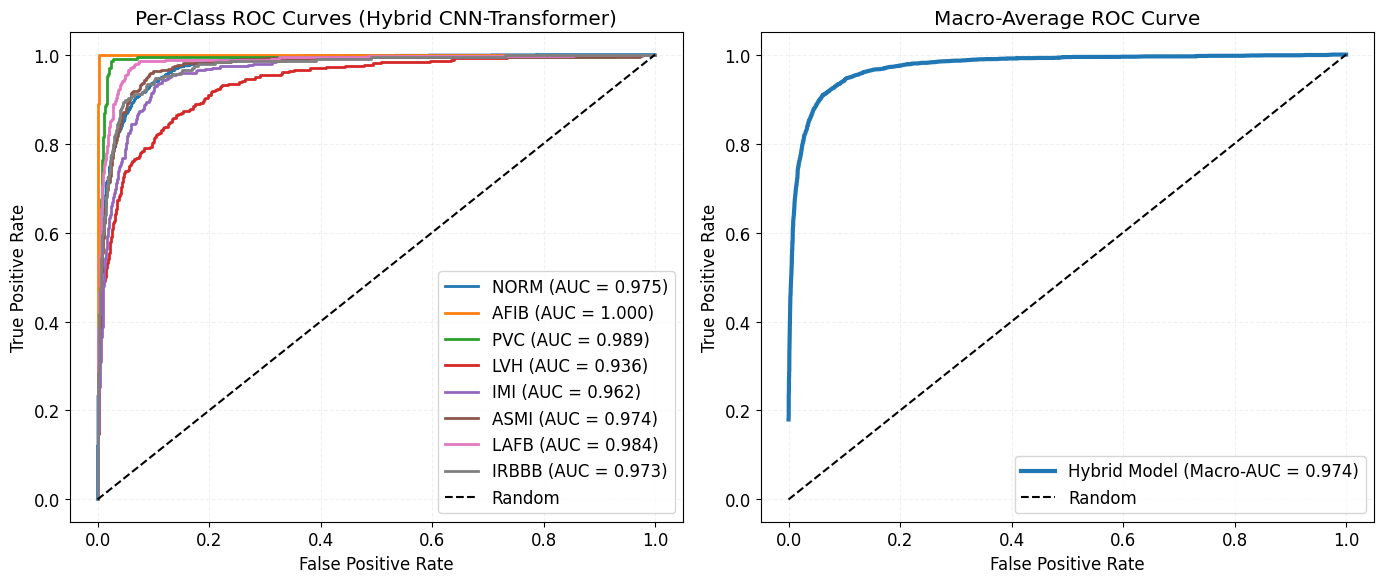


 ROC figure saved as: Hybrid_roc_curves.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
# FORCE CLEAN WHITE BACKGROUND
plt.style.use('default')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': True,
    'grid.color': 'lightgray',
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 12
})
# SAFETY CHECK
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

assert y_true.shape == y_pred.shape, "Mismatch between labels and predictions!"

# CLASS NAMES
class_names = ['NORM','AFIB','PVC','LVH','IMI','ASMI','LAFB','IRBBB']
n_classes = len(class_names)

# COMPUTE ROC FOR EACH CLASS
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# MACRO-AVERAGE ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

# Verify with sklearn
macro_auc_sklearn = roc_auc_score(y_true, y_pred, average='macro')

print(f"\nManual Macro-AUC:   {macro_auc:.4f}")
print(f"Sklearn Macro-AUC:  {macro_auc_sklearn:.4f}")

# PLOTTING
plt.rcParams.update({'font.size': 12})

plt.figure(figsize=(14,6))

# ---- Left: Per-Class ROC ----
plt.subplot(1,2,1)

for i in range(n_classes):
    plt.plot(
        fpr[i], 
        tpr[i], 
        lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0,1],[0,1],'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves (Hybrid CNN-Transformer)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# ---- Right: Macro ROC ----
plt.subplot(1,2,2)

plt.plot(
    all_fpr, 
    mean_tpr, 
    lw=3,
    label=f"Hybrid Model (Macro-AUC = {macro_auc:.3f})"
)

plt.plot([0,1],[0,1],'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save high-quality figure
#plt.savefig("hybrid_roc_curves.png", dpi=300, bbox_inches="tight")

plt.show()

print("\n ROC figure saved as: Hybrid_roc_curves.png")

In [15]:
wandb.finish()

epoch,▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
train_accuracy,▁▅▅▅▆▆▆▆▆▆▇▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇▇█▇███████████
train_loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_auc,▁▅▆▇▆███████████████████████████████████
epoch,100
train_accuracy,0.73436
train_loss,0.19408
val_auc,0.97159


In [12]:
print(type(model))
print(next(model.parameters()).device)
print(len(test_dataset))

<class '__main__.OptimizedHybrid'>
cuda:0
3576


In [13]:
#Add GRAD-CAM FUNCTION
import torch
import numpy as np

def gradcam_1d(model, input_signal, target_class, device):

    model.eval()

    # Ensure correct device
    input_signal = input_signal.to(device)

    # Ensure shape is (B, C, T)
    if input_signal.dim() == 2:   # (12, 1000)
        input_signal = input_signal.unsqueeze(0)

    assert input_signal.dim() == 3, \
        f"Expected (B, C, T), got {input_signal.shape}"

    gradients = []
    activations = []

    # Forward hook
    def forward_hook(module, input, output):
        activations.append(output)

    # Backward hook
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Attach hook to last CNN block
    handle_forward = model.cnn4.register_forward_hook(forward_hook)
    handle_backward = model.cnn4.register_full_backward_hook(backward_hook)

    # Forward pass
    output = model(input_signal)

    # Multi-label safe backward
    score = output[:, target_class]

    model.zero_grad()
    score.backward(torch.ones_like(score))

    # Extract gradients & activations
    grads = gradients[0].detach().cpu().numpy()[0]   # (C, T)
    acts = activations[0].detach().cpu().numpy()[0]  # (C, T)

    # Remove hooks
    handle_forward.remove()
    handle_backward.remove()

    # Global average pooling
    weights = np.mean(grads, axis=1)

    # Weighted combination
    cam = np.zeros(acts.shape[1])
    for i, w in enumerate(weights):
        cam += w * acts[i]

    # ReLU
    cam = np.maximum(cam, 0)

    # Normalize
    cam = cam / (np.max(cam) + 1e-8)

    return cam
    return cam

In [14]:
afib_index = target_labels.index("AFIB")

afib_samples = []

for i in range(len(test_dataset)):
    signal, label = test_dataset[i]

    # handle tensor labels safely
    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]

    if label_val == 1:
        afib_samples.append(signal)

    if len(afib_samples) == 50:
        break

print("Collected AFIB samples:", len(afib_samples))

Collected AFIB samples: 50


In [15]:
global_cams = []

for signal in afib_samples:

    cam = gradcam_1d(model, signal, afib_index, device)

    # Resize to 1000
    x_original = np.linspace(0, len(cam)-1, len(cam))
    x_target = np.linspace(0, len(cam)-1, 1000)

    cam_resized = np.interp(x_target, x_original, cam)

    global_cams.append(cam_resized)

global_cams = np.array(global_cams)

print(global_cams.shape)

(50, 1000)


In [16]:
mean_cam = global_cams.mean(axis=0)
print(mean_cam.shape)  # (1000,)

(1000,)


In [17]:
global_cams = np.array(global_cams)

print(type(global_cams))  # should show <class 'numpy.ndarray'>
print(global_cams.shape)  # should show (50, 1000)

<class 'numpy.ndarray'>
(50, 1000)


In [18]:
# Get AFIB class index
afib_index = target_labels.index("AFIB")

# Find one AFIB example
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]

    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]

    if label_val == 1:
        sample_signal = signal
        print("Using AFIB sample at index:", i)
        break

Using AFIB sample at index: 12


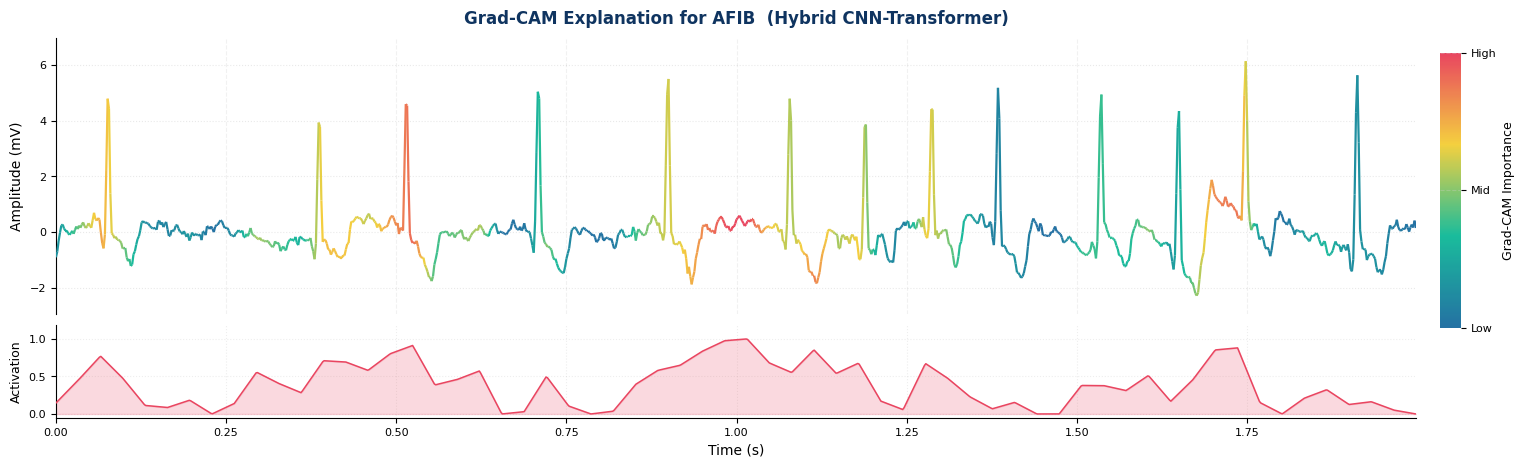

In [19]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
#── Same colormap as the grid plots ──────────────────────────────────────────
GRADCAM_CMAP = LinearSegmentedColormap.from_list(
    "thesis_gradcam",
    ["#2471A3", "#1ABC9C", "#F4D03F", "#E94560"],
    N=256,
)

# ── Your existing variables (no changes needed) ───────────────────────────────
lead_index  = 0
signal      = sample_signal[lead_index].numpy()
cam         = (cam_resized - cam_resized.min()) / (np.ptp(cam_resized) + 1e-8)
t           = np.arange(len(signal)) / 500   # seconds (change 500 to your fs)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5), facecolor="white")
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1],
                        hspace=0.06, left=0.07, right=0.92,
                        top=0.88, bottom=0.12)

# ── Top: ECG coloured by GradCAM ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("white")

points = np.array([t, signal]).T.reshape(-1, 1, 2)
segs   = np.concatenate([points[:-1], points[1:]], axis=1)
lc     = LineCollection(segs, cmap=GRADCAM_CMAP,
                        norm=plt.Normalize(0, 1),
                        linewidth=1.6, zorder=3)
lc.set_array(cam[:-1])
ax1.add_collection(lc)

ax1.set_xlim(t[0], t[-1])
ax1.set_ylim(signal.min() - 0.08 * np.ptp(signal),
             signal.max() + 0.10 * np.ptp(signal))

ax1.set_title("Grad-CAM Explanation for AFIB  (Hybrid CNN-Transformer)",
              fontsize=12, fontweight="bold", color="#0F3460", pad=10)
ax1.set_ylabel("Amplitude (mV)", fontsize=10)
ax1.set_xticklabels([])
ax1.tick_params(bottom=False, labelsize=8)
ax1.spines[["top", "right", "bottom"]].set_visible(False)
ax1.grid(axis="y", linestyle=":", alpha=0.25, color="#AAAAAA")

# Colorbar
cbar_ax = fig.add_axes([0.935, 0.30, 0.013, 0.55])
sm = plt.cm.ScalarMappable(cmap=GRADCAM_CMAP, norm=plt.Normalize(0, 1))
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label("Grad-CAM Importance", fontsize=9)
cb.set_ticks([0, 0.5, 1.0])
cb.set_ticklabels(["Low", "Mid", "High"])
cb.ax.tick_params(labelsize=8)
cb.outline.set_visible(False)

# ── Bottom: activation fill curve ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor("white")
ax2.plot(t, cam, color="#E94560", linewidth=1.1, zorder=3)
ax2.fill_between(t, cam, alpha=0.20, color="#E94560", zorder=2)
ax2.set_xlim(t[0], t[-1])
ax2.set_ylim(-0.05, 1.18)
ax2.set_xlabel("Time (s)", fontsize=10)
ax2.set_ylabel("Activation", fontsize=9)
ax2.tick_params(labelsize=8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(linestyle=":", alpha=0.2, color="#AAAAAA")

plt.savefig(
    "/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/gradcam_afib.pdf",
    dpi=300, bbox_inches="tight", facecolor="white",
)
plt.show()


In [20]:
#SHAP Interpretability
!pip install shap wfdb matplotlib numpy torch -q

In [21]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
import gc
torch.cuda.empty_cache()
gc.collect()

from tqdm import tqdm


In [22]:
model = model.cpu()
model.eval()

OptimizedHybrid(
  (cnn1): ResidualCNNBlock(
    (conv1): Conv1d(12, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv1d(12, 64, kernel_size=(1,), stride=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (relu): ReLU(inplace=True)
  )
  (cnn2): ResidualCNNBlock(
    (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, a

In [23]:
afib_index = target_labels.index("AFIB")

afib_samples = []

for i in range(len(test_dataset)):
    signal, label = test_dataset[i]

    if label[afib_index] == 1:
        afib_samples.append(signal.numpy())

    if len(afib_samples) == 10:
        break

afib_samples = np.array(afib_samples)

print(afib_samples.shape)

(10, 12, 1000)


In [24]:
n_bins = 50
segment_length = 1000 // n_bins

signals_reduced = afib_samples.reshape(
    afib_samples.shape[0],
    12,
    n_bins,
    segment_length
).mean(axis=3)

print(signals_reduced.shape)

(10, 12, 50)


In [25]:
signals_flat = signals_reduced.reshape(signals_reduced.shape[0], -1)

print(signals_flat.shape)

(10, 600)


In [26]:
def model_predict(x):

    x = np.array(x)

    # reshape back to ECG
    x = x.reshape(x.shape[0], 12, 50)

    # expand bins back to 1000 timepoints
    x = np.repeat(x, 20, axis=2)

    x = torch.tensor(x).float()

    with torch.no_grad():
        preds = model(x).numpy()

    return preds

In [27]:
background = signals_flat[:5]

In [28]:
explainer = shap.KernelExplainer(model_predict, background)

In [29]:
shap_values = explainer.shap_values(
    signals_flat[:2],
    nsamples=50
)

100%|██████████| 2/2 [00:02<00:00,  1.33s/it]


In [30]:
afib_shap = shap_values[afib_index]

afib_shap = afib_shap.reshape(-1, 12, 50)

print(afib_shap.shape)

(8, 12, 50)


In [31]:
# convert SHAP to lead importance
lead_shap = np.mean(np.abs(afib_shap), axis=2)

print(lead_shap.shape)

(8, 12)


In [32]:
print("SHAP tensor:", afib_shap.shape)
print("Lead SHAP:", lead_shap.shape)

SHAP tensor: (8, 12, 50)
Lead SHAP: (8, 12)


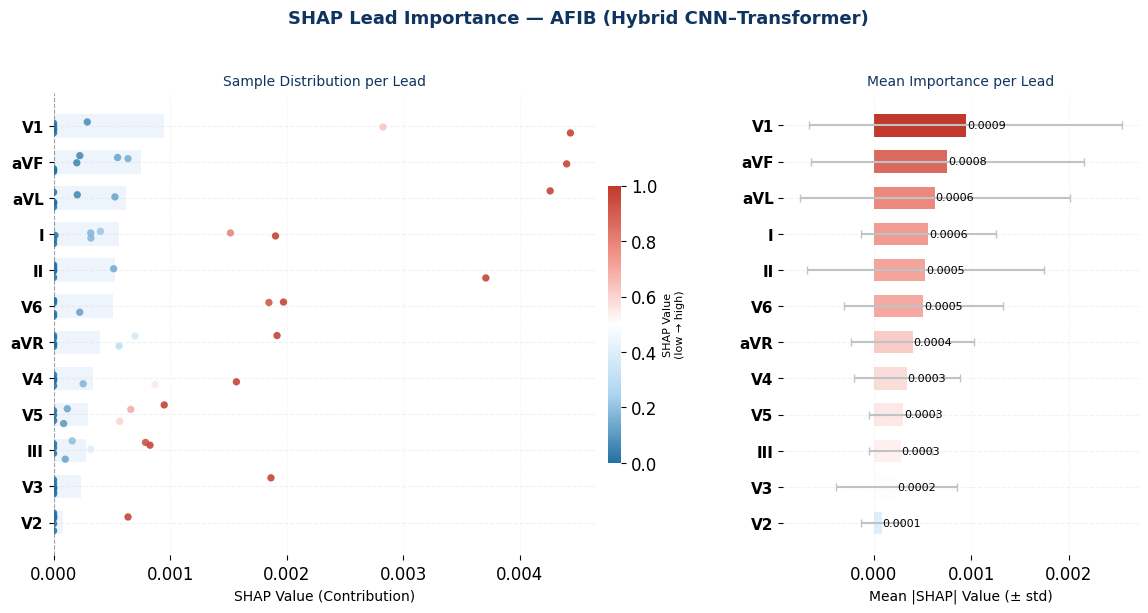

[✓] Saved → Figures/shap_lead_importance.pdf


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── Colormap ───────────────────────────────────────────────────────────────
SHAP_CMAP = LinearSegmentedColormap.from_list(
    "thesis_shap",
    ["#2471A3", "#AED6F1", "#FFFFFF", "#F1948A", "#C0392B"],
    N=256,
)

PALETTE = {
    "bg": "#FFFFFF",
    "text": "#1A1A2E",
    "blue": "#0F3460",
    "light": "#EAF2FB",
    "neutral": "#BDC3C7",
    "accent": "#E94560",
}

lead_names = ["I","II","III","aVR","aVL","aVF",
              "V1","V2","V3","V4","V5","V6"]

# ── Compute SHAP importance correctly ───────────────────────────────────────
lead_shap_abs = np.abs(lead_shap)

mean_importance = lead_shap_abs.mean(axis=0)
std_importance  = lead_shap_abs.std(axis=0)

# Sort leads by importance
order = np.argsort(mean_importance)
sorted_names = [lead_names[i] for i in order]

# ── Figure ──────────────────────────────────────────────────────────────────
fig, (ax_bee, ax_bar) = plt.subplots(
    1, 2,
    figsize=(14,6),
    gridspec_kw={"width_ratios":[1.6,1], "wspace":0.35},
    facecolor=PALETTE["bg"]
)

fig.suptitle(
    "SHAP Lead Importance — AFIB (Hybrid CNN–Transformer)",
    fontsize=13,
    fontweight="bold",
    color=PALETTE["blue"],
    y=1.02
)

# ────────────────────────────────────────────────────────────────────────────
# Beeswarm plot
# ────────────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

for plot_row, lead_i in enumerate(order):

    vals = lead_shap[:, lead_i]
    jitter = rng.uniform(-0.28,0.28,size=len(vals))

    norm_vals = (vals - vals.min()) / (np.ptp(vals) + 1e-8)
    colors = SHAP_CMAP(norm_vals)

    ax_bee.barh(
        plot_row,
        mean_importance[lead_i],
        height=0.65,
        color=PALETTE["light"],
        alpha=0.8,
        zorder=1
    )

    ax_bee.scatter(
        vals,
        plot_row + jitter,
        c=colors,
        s=28,
        alpha=0.85,
        linewidths=0,
        zorder=3
    )

ax_bee.axvline(0, color=PALETTE["text"], lw=0.8, ls="--", alpha=0.4)

ax_bee.set_yticks(range(12))
ax_bee.set_yticklabels(sorted_names, fontsize=11, fontweight="bold")
ax_bee.set_xlabel("SHAP Value (Contribution)", fontsize=10)
ax_bee.set_title("Sample Distribution per Lead", fontsize=10, color=PALETTE["blue"])
ax_bee.grid(axis="x", ls=":", alpha=0.25, color=PALETTE["neutral"])
ax_bee.spines[:].set_visible(False)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=SHAP_CMAP)
sm.set_array([])

cb = plt.colorbar(sm, ax=ax_bee, fraction=0.025, pad=0.02, shrink=0.6)
cb.set_label("SHAP Value\n(low → high)", fontsize=8)
cb.outline.set_visible(False)

# ────────────────────────────────────────────────────────────────────────────
# Bar chart
# ────────────────────────────────────────────────────────────────────────────
vals_sorted = mean_importance[order]
errs_sorted = std_importance[order]

norm_vals = (vals_sorted - vals_sorted.min()) / (np.ptp(vals_sorted) + 1e-8)
bar_colors = [SHAP_CMAP(0.4 + 0.6*v) for v in norm_vals]

bars = ax_bar.barh(
    range(12),
    vals_sorted,
    height=0.62,
    color=bar_colors,
    edgecolor="none",
    xerr=errs_sorted,
    error_kw=dict(ecolor=PALETTE["neutral"], capsize=3)
)

for bar, v in zip(bars, vals_sorted):
    ax_bar.text(
        v + vals_sorted.max()*0.01,
        bar.get_y()+bar.get_height()/2,
        f"{v:.4f}",
        va="center",
        fontsize=8
    )

ax_bar.set_yticks(range(12))
ax_bar.set_yticklabels(sorted_names, fontsize=11, fontweight="bold")
ax_bar.set_xlabel("Mean |SHAP| Value (± std)", fontsize=10)
ax_bar.set_title("Mean Importance per Lead", fontsize=10, color=PALETTE["blue"])
ax_bar.grid(axis="x", ls=":", alpha=0.25, color=PALETTE["neutral"])
ax_bar.spines[:].set_visible(False)

plt.tight_layout()

plt.savefig(
    "/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/shap_lead_importance.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("[✓] Saved → Figures/shap_lead_importance.pdf")

In [34]:
# CHECK DATA 
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_true sample row:", y_true[0])
print("y_pred sample row:", y_pred[0])

y_true shape: (3576, 8)
y_pred shape: (3576, 8)
y_true sample row: [1. 0. 0. 0. 0. 0. 0. 0.]
y_pred sample row: [0.5209392  0.4460102  0.4590808  0.7321486  0.5458554  0.34972537
 0.3879935  0.51345456]


In [35]:
# THRESHOLD OPTIMIZATION
from sklearn.metrics import f1_score
import numpy as np

best_thresholds = []
for i in range(y_true.shape[1]):
    best_thresh = 0.5
    best_f1 = 0.0
    for thresh in np.arange(0.1, 0.9, 0.05):
        y_pred_bin = (y_pred[:, i] >= thresh).astype(int)
        f1 = f1_score(y_true[:, i], y_pred_bin, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    best_thresholds.append(best_thresh)
    print(f"{target_labels[i]}: threshold={best_thresh:.2f} | F1={best_f1:.3f}")

print("Best thresholds:", best_thresholds)

NORM: threshold=0.35 | F1=0.825
AFIB: threshold=0.70 | F1=0.825
PVC: threshold=0.85 | F1=0.810
LVH: threshold=0.85 | F1=0.504
IMI: threshold=0.75 | F1=0.438
ASMI: threshold=0.75 | F1=0.646
LAFB: threshold=0.75 | F1=0.694
IRBBB: threshold=0.85 | F1=0.623
Best thresholds: [np.float64(0.3500000000000001), np.float64(0.7000000000000002), np.float64(0.8500000000000002), np.float64(0.8500000000000002), np.float64(0.7500000000000002), np.float64(0.7500000000000002), np.float64(0.7500000000000002), np.float64(0.8500000000000002)]


NORM: threshold=0.35 | F1=0.825
AFIB: threshold=0.70 | F1=0.825
PVC: threshold=0.85 | F1=0.810
LVH: threshold=0.85 | F1=0.504
IMI: threshold=0.75 | F1=0.438
ASMI: threshold=0.75 | F1=0.646
LAFB: threshold=0.75 | F1=0.694
IRBBB: threshold=0.85 | F1=0.623


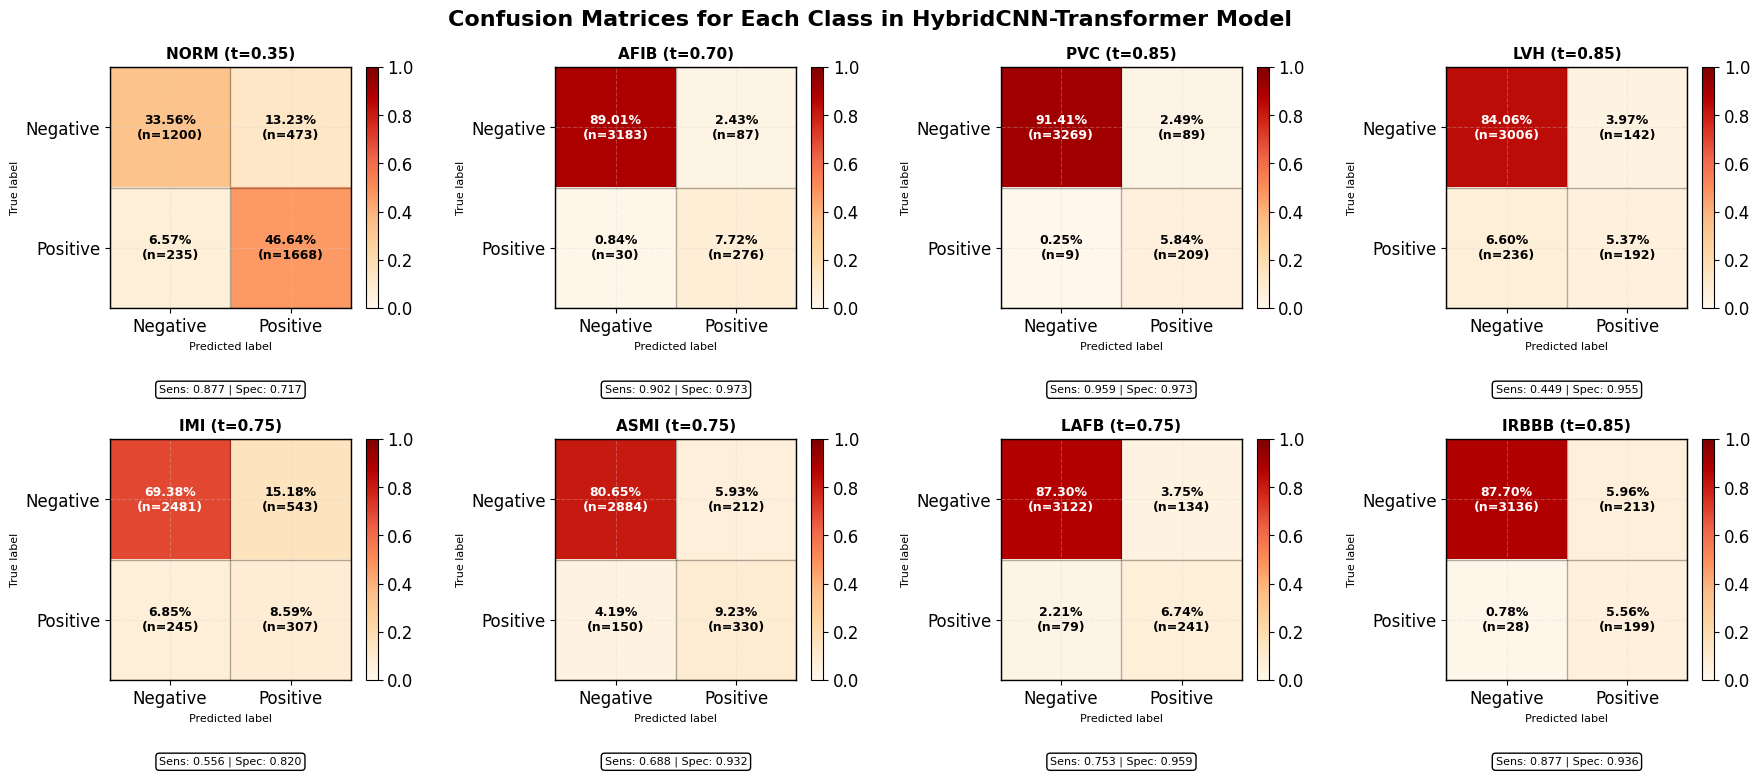

In [39]:
#CONFUSION MATRICES
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score

class_names = target_labels
n_classes = len(class_names)

# Find best threshold per class
best_thresholds = []
for i in range(y_true.shape[1]):
    best_thresh = 0.5
    best_f1 = 0.0
    for thresh in np.arange(0.1, 0.9, 0.05):
        y_pred_bin = (y_pred[:, i] >= thresh).astype(int)
        f1 = f1_score(y_true[:, i], y_pred_bin, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    best_thresholds.append(best_thresh)
    print(f"{class_names[i]}: threshold={best_thresh:.2f} | F1={best_f1:.3f}")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, ax in enumerate(axes.flat):

    # Multi-label: per-class binary with tuned threshold
    y_true_bin = y_true[:, i].astype(int)
    y_pred_bin = (y_pred[:, i] >= best_thresholds[i]).astype(int)

    cm = confusion_matrix(y_true_bin, y_pred_bin)
    TN, FP, FN, TP = cm.ravel()

    total = cm.sum()
    cm_prop = cm / total

    im = ax.imshow(cm_prop, cmap="OrRd", vmin=0, vmax=1)

    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    for r in range(2):
        for c in range(2):
            count = cm[r, c]
            percent = cm_prop[r, c] * 100
            color = "white" if cm_prop[r, c] > 0.5 else "black"
            ax.text(c, r, f"{percent:.2f}%\n(n={count})",
                    ha="center", va="center",
                    fontsize=9, fontweight="bold", color=color)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])
    ax.set_xlabel("Predicted label", fontsize=8)
    ax.set_ylabel("True label", fontsize=8)

    # Show threshold used in title
    ax.set_title(f"{class_names[i]} (t={best_thresholds[i]:.2f})",
                 fontsize=11, fontweight="bold")

    sens = TP / (TP + FN) if (TP + FN) > 0 else 0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0

    ax.text(0.5, -0.35,
            f"Sens: {sens:.3f} | Spec: {spec:.3f}",
            transform=ax.transAxes, ha="center", fontsize=8,
            bbox=dict(facecolor="white", edgecolor="black",
                      boxstyle="round,pad=0.3"))

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1)

    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Confusion Matrices for Each Class in HybridCNN-Transformer Model",
             fontsize=16, fontweight="bold")
plt.tight_layout()
#plt.savefig("confusion_matrix_hybrid.png", dpi=300, bbox_inches='tight')
plt.show()